In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1321.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1432.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1321.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1232.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_CSV.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1232.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1432.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1523.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_excel.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1523.xlsx


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_CSV.csv', header=[0], skiprows=[1,2,3])
df = df.rename(columns={'VE/': 'VE/VO2', 'VE/.1': 'VE/VCO2'})

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TIME     55 non-null     float64
 1   VO2      55 non-null     float64
 2   VO2/kg   55 non-null     float64
 3   METS     55 non-null     float64
 4   VCO2     55 non-null     float64
 5   VE       55 non-null     float64
 6   RER      55 non-null     float64
 7   RR       55 non-null     float64
 8   Vt       55 non-null     float64
 9   FEO2     55 non-null     float64
 10  FECO2    55 non-null     float64
 11  HR       55 non-null     float64
 12  VE/VO2   55 non-null     float64
 13  VE/VCO2  55 non-null     float64
 14  PetCO2   55 non-null     float64
 15  Power    55 non-null     int64  
dtypes: float64(15), int64(1)
memory usage: 7.0 KB


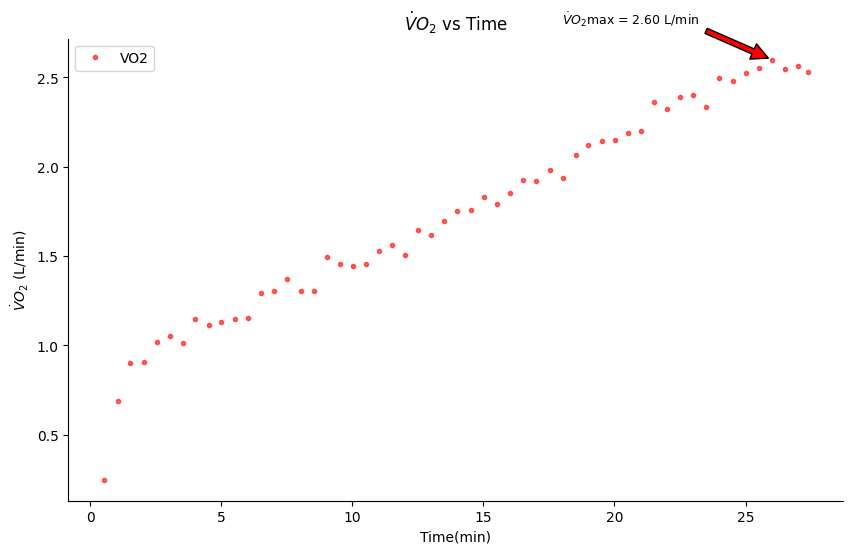

In [4]:
fig, ax = plt.subplots(figsize=(10,6))

# VO2 vs Time
vo2_max = df['VO2'].max()
time_max = df['TIME'][df['VO2'].idxmax()]

ax.annotate(r'$\dot{{V}}O_2$max = {:.2f} L/min'.format(round(vo2_max, 2)),
            xy=(time_max, vo2_max),
            xytext=(time_max - 8, vo2_max + 0.2),
            arrowprops=dict(facecolor='red', shrink=0.05),
            fontsize=9)

ax.plot(df['TIME'], df['VO2'], 'o', color='red',
           markersize=3, alpha=0.6, label='VO2')
ax.set_xlabel('Time(min)')
ax.set_ylabel(r'$\dot{V}O_2$ (L/min)')
ax.set_title(r'$\dot{V}O_2$ vs Time')
ax.legend(loc='upper left')
ax.spines[['right', 'top']].set_visible(False)

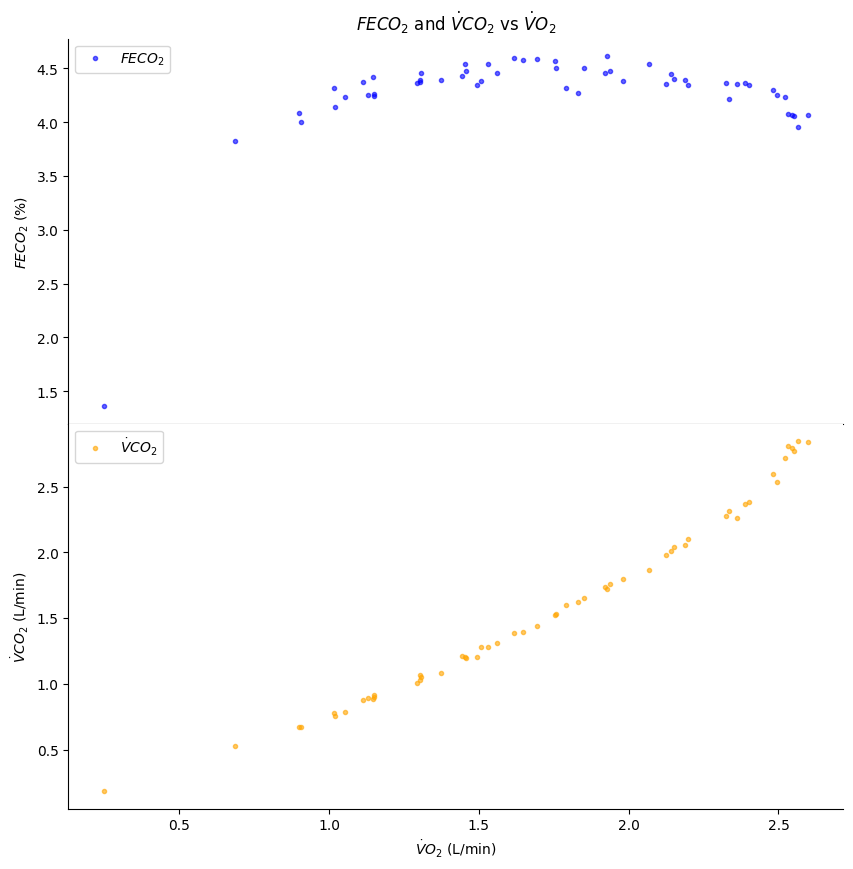

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),
                               sharex=True)
fig.subplots_adjust(hspace=0)

# FECO2 vs VO2
ax1.plot(df['VO2'], df['FECO2'], 'o', color='blue',
           markersize=3, alpha=0.6, label=r'$FECO_2$')
ax1.set_ylabel(r'$FECO_2$ (%)')
ax1.set_title(r'$FECO_2$ and $\dot{V}CO_2$ vs $\dot{V}O_2$')
ax1.legend(loc='upper left')
ax1.spines[['right', 'top']].set_visible(False)


# VCO2 vs VO2
ax2.plot(df['VO2'], df['VCO2'], 'o', color='orange',
           markersize=3, alpha=0.6, label=r'$\dot{V}CO_2$')
ax2.set_xlabel(r'$\dot{V}O_2$ (L/min)')
ax2.set_ylabel(r'$\dot{V}CO_2$ (L/min)')
ax2.legend(loc='upper left')
ax2.spines[['right', 'top']].set_visible(False)

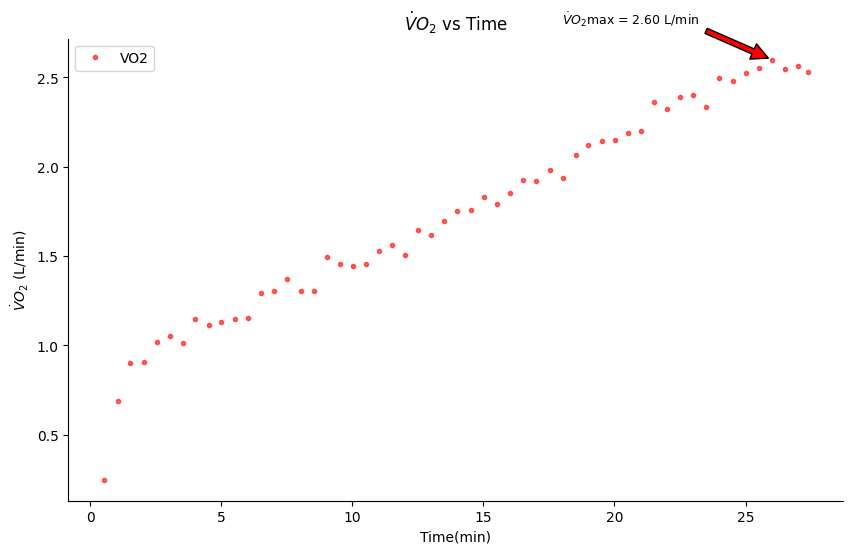

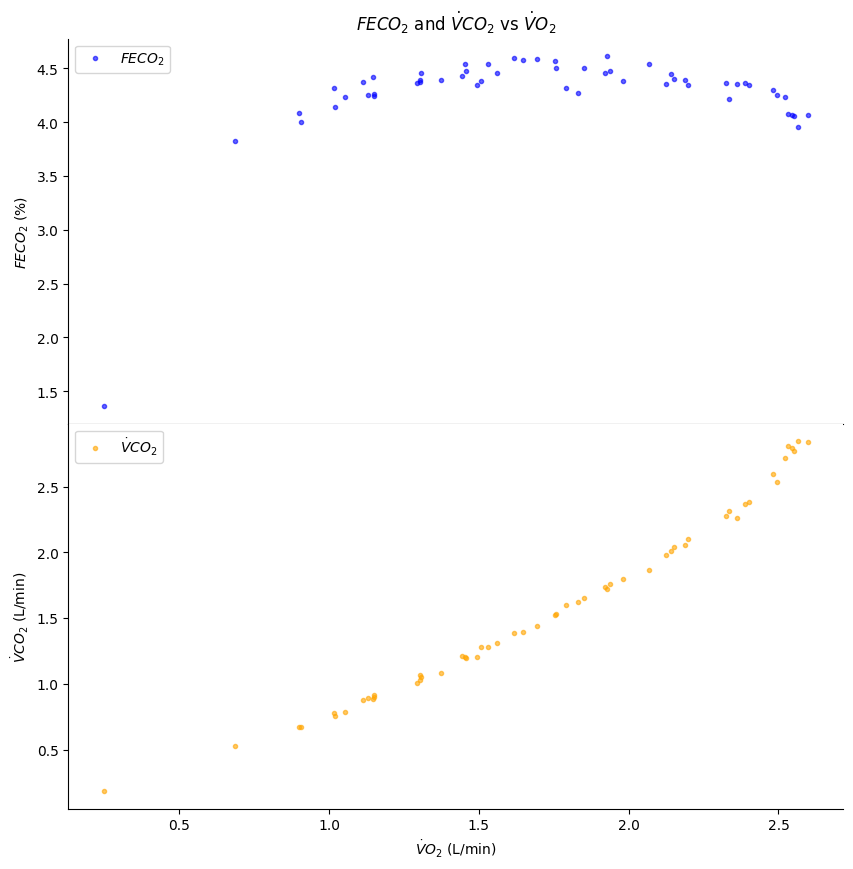

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_CSV.csv', header=[0], skiprows=[1,2,3])
df = df.rename(columns={'VE/': 'VE/VO2', 'VE/.1': 'VE/VCO2'})

# ── Physiological Thresholds ────────────────────────────────────────────────
# GET (Gas Exchange Threshold / T1): VO₂ where VCO₂ begins to rise
#   non-linearly, identified visually via the V-slope method.
# RCP (Respiratory Compensation Point / T2): VO₂ where FECO₂ drops after
#   its plateau, indicating hyperventilation onset.

GET_vo2 = 1.4  # L/min  
RCP_vo2 = 2.2  # L/min  

# Primary VO2 Figure
fig, ax = plt.subplots(figsize=(10,6))

# VO2 vs Time
vo2_max = df['VO2'].max()
time_max = df['TIME'][df['VO2'].idxmax()]

ax.annotate(r'$\dot{{V}}O_2$max = {:.2f} L/min'.format(round(vo2_max, 2)),
            xy=(time_max, vo2_max),
            xytext=(time_max - 8, vo2_max + 0.2),
            arrowprops=dict(facecolor='red', shrink=0.05),
            fontsize=9)

ax.plot(df['TIME'], df['VO2'], 'o', color='red',
           markersize=3, alpha=0.6, label='VO2')
ax.set_xlabel('Time(min)')
ax.set_ylabel(r'$\dot{V}O_2$ (L/min)')
ax.set_title(r'$\dot{V}O_2$ vs Time')
ax.legend(loc='upper left')
ax.spines[['right', 'top']].set_visible(False)

# Gas Exchange Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),
                               sharex=True)
fig.subplots_adjust(hspace=0)

# FECO2 vs VO2
ax1.plot(df['VO2'], df['FECO2'], 'o', color='blue',
           markersize=3, alpha=0.6, label=r'$FECO_2$')
ax1.set_ylabel(r'$FECO_2$ (%)')
ax1.set_title(r'$FECO_2$ and $\dot{V}CO_2$ vs $\dot{V}O_2$')
ax1.legend(loc='upper left')
ax1.spines[['right', 'top']].set_visible(False)


# VCO2 vs VO2
ax2.plot(df['VO2'], df['VCO2'], 'o', color='orange',
           markersize=3, alpha=0.6, label=r'$\dot{V}CO_2$')
ax2.set_xlabel(r'$\dot{V}O_2$ (L/min)')
ax2.set_ylabel(r'$\dot{V}CO_2$ (L/min)')
ax2.legend(loc='upper left')
ax2.spines[['right', 'top']].set_visible(False)

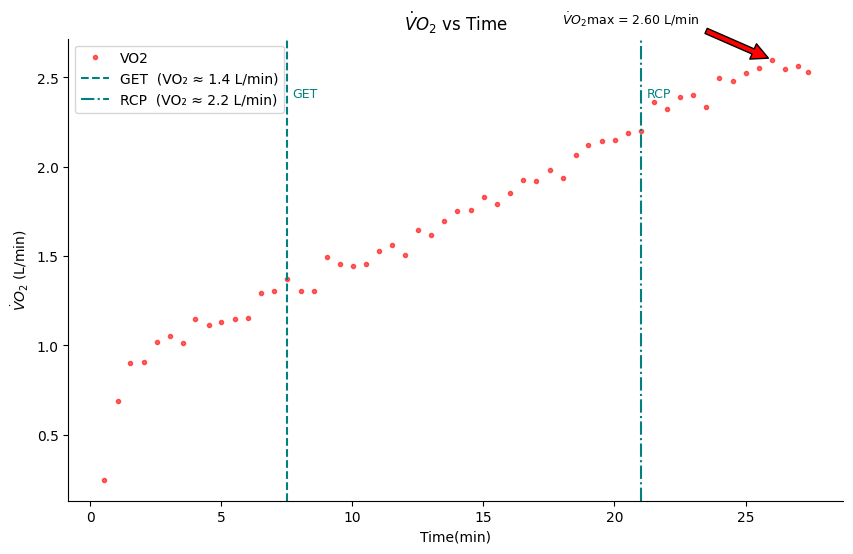

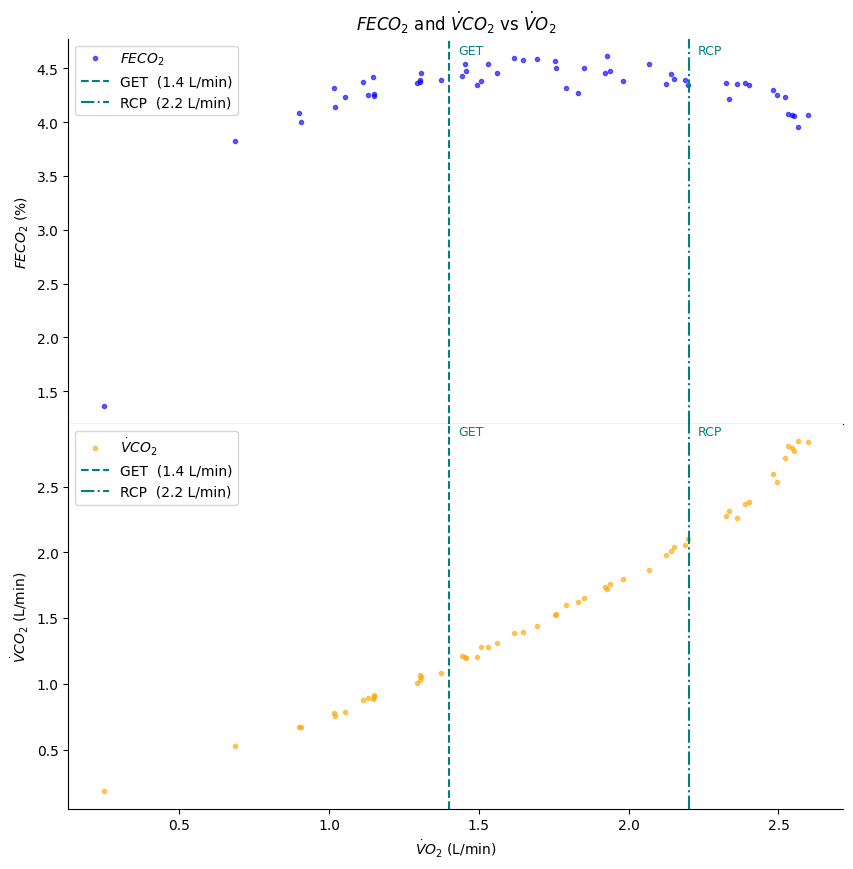

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_CSV.csv', header=[0], skiprows=[1,2,3])
df = df.rename(columns={'VE/': 'VE/VO2', 'VE/.1': 'VE/VCO2'})

# ── Physiological Thresholds ────────────────────────────────────────────────
# GET (Gas Exchange Threshold / T1): VO₂ where VCO₂ begins to rise
#   non-linearly, identified visually via the V-slope method.
# RCP (Respiratory Compensation Point / T2): VO₂ where FECO₂ drops after
#   its plateau, indicating hyperventilation onset.

GET_vo2 = 1.4  # L/min  
RCP_vo2 = 2.2  # L/min  

# Primary VO2 Figure
fig, ax = plt.subplots(figsize=(10,6))

# VO2 vs Time
vo2_max = df['VO2'].max()
time_max = df['TIME'][df['VO2'].idxmax()]

ax.annotate(r'$\dot{{V}}O_2$max = {:.2f} L/min'.format(round(vo2_max, 2)),
            xy=(time_max, vo2_max),
            xytext=(time_max - 8, vo2_max + 0.2),
            arrowprops=dict(facecolor='red', shrink=0.05),
            fontsize=9)

ax.plot(df['TIME'], df['VO2'], 'o', color='red',
           markersize=3, alpha=0.6, label='VO2')

# Find the time point closest to each VO₂ threshold
time_GET = df.loc[(df['VO2'] - GET_vo2).abs().idxmin(), 'TIME']
time_RCP = df.loc[(df['VO2'] - RCP_vo2).abs().idxmin(), 'TIME']

ax.axvline(time_GET, color='teal', linewidth=1.5, linestyle='--',
           label=f'GET  (VO₂ ≈ {GET_vo2} L/min)')
ax.axvline(time_RCP, color='teal', linewidth=1.5, linestyle='-.',
           label=f'RCP  (VO₂ ≈ {RCP_vo2} L/min)')

# Label lines directly on the plot
ax.text(time_GET + 0.2, vo2_max * 0.92, 'GET', color='teal', fontsize=9)
ax.text(time_RCP + 0.2, vo2_max * 0.92, 'RCP', color='teal', fontsize=9)

ax.set_xlabel('Time(min)')
ax.set_ylabel(r'$\dot{V}O_2$ (L/min)')
ax.set_title(r'$\dot{V}O_2$ vs Time')
ax.legend(loc='upper left')
ax.spines[['right', 'top']].set_visible(False)

# Gas Exchange Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig.subplots_adjust(hspace=0)

# FECO2 vs VO2
ax1.plot(df['VO2'], df['FECO2'], 'o', color='blue',
           markersize=3, alpha=0.6, label=r'$FECO_2$')
ax1.axvline(GET_vo2, color='teal', linewidth=1.5, linestyle='--',
            label=f'GET  ({GET_vo2} L/min)')
ax1.axvline(RCP_vo2, color='teal', linewidth=1.5, linestyle='-.',
            label=f'RCP  ({RCP_vo2} L/min)')
ax1.text(GET_vo2 + 0.03, ax1.get_ylim()[1] * 0.97, 'GET', color='teal', fontsize=9)
ax1.text(RCP_vo2 + 0.03, ax1.get_ylim()[1] * 0.97, 'RCP', color='teal', fontsize=9)
ax1.set_ylabel(r'$FECO_2$ (%)')
ax1.set_title(r'$FECO_2$ and $\dot{V}CO_2$ vs $\dot{V}O_2$')
ax1.legend(loc='upper left')
ax1.spines[['right', 'top']].set_visible(False)

# VCO2 vs VO2
ax2.plot(df['VO2'], df['VCO2'], 'o', color='orange',
           markersize=3, alpha=0.6, label=r'$\dot{V}CO_2$')
ax2.axvline(GET_vo2, color='teal', linewidth=1.5, linestyle='--',
            label=f'GET  ({GET_vo2} L/min)')
ax2.axvline(RCP_vo2, color='teal', linewidth=1.5, linestyle='-.',
            label=f'RCP  ({RCP_vo2} L/min)')
ax2.text(GET_vo2 + 0.03, ax2.get_ylim()[1] * 0.97, 'GET', color='teal', fontsize=9)
ax2.text(RCP_vo2 + 0.03, ax2.get_ylim()[1] * 0.97, 'RCP', color='teal', fontsize=9)
ax2.set_xlabel(r'$\dot{V}O_2$ (L/min)')
ax2.set_ylabel(r'$\dot{V}CO_2$ (L/min)')
ax2.legend(loc='upper left')
ax2.spines[['right', 'top']].set_visible(False)